In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
# set ../ as the path to the parent directory
sys.path.append('../model_exploration')

In [3]:
from utils import build_dataset_configs, load_and_cache_datasets

/rhome/sawale/miniconda3/envs/slurm-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/rhome/sawale/miniconda3/envs/slurm-test/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/nas/rhome/sawale/miniconda3/envs/slurm-test/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
NROWS = 100
N_DATA_SRC=None

configs = build_dataset_configs(N_DATA_SRC)
ds_dict = load_and_cache_datasets(configs, f"../data/stage1_cache/NROWS_{NROWS}", NROWS, rank=0)

RANK:0;▶ Processing: squad_v2
RANK:0;▶ Processing: wikipedia
RANK:0;▶ Processing: StackExchange_Math_titlebody_answer
RANK:0;▶ Processing: StackExchange_Math_title_answer
RANK:0;▶ Processing: StackExchange_title_body
RANK:0;▶ Processing: StackExchange_Duplicates_titlebody_titlebody
RANK:0;▶ Processing: StackExchange_Duplicates_body_body
RANK:0;▶ Processing: StackExchange_Duplicates_title_title
RANK:0;▶ Processing: Natural_Questions
RANK:0;▶ Processing: PAQ
RANK:0;▶ Processing: Gooaq
RANK:0;▶ Processing: yahoo_title_answers
RANK:0;▶ Processing: msmacro_triplet
RANK:0;▶ Processing: trivia_qa_triplet
RANK:0;▶ Processing: nli_for_simcse_triplet
RANK:0;▶ Processing: quora_dup_triplet
RANK:0;▶ Processing: WikiAnswers
RANK:0;▶ Processing: eli5
RANK:0;▶ Processing: sentence_compression
RANK:0;▶ Processing: Flickr30k_Captions
RANK:0;▶ Processing: Coco_Captions
RANK:0;▶ Processing: xsum
RANK:0;▶ Processing: agnews
RANK:0;▶ Processing: npr
RANK:0;▶ Processing: cnn_dailymail
RANK:0;▶ Processing: c

In [5]:
ds_dict

{'squad_v2': DatasetDict({
     train: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 90
     })
     validation: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
     test: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
 }),
 'wikipedia': DatasetDict({
     train: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 90
     })
     validation: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
     test: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
 }),
 'StackExchange_Math_titlebody_answer': DatasetDict({
     train: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 90
     })
     validation: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
     test: Dataset({
         features: ['anchor', 'positive'],
         num_rows: 5
     })
 }),
 'StackExchange

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoTokenizer

# load your tokenizer
tokenizer = AutoTokenizer.from_pretrained("nomic-ai/modernbert-embed-base")


# 1️⃣ Gather token counts using the HF tokenizer
anchor_lens = []
positive_lens = []
for splits in ds_dict.values():
    for row in splits['train']:
        # tokenize without adding special tokens ([CLS], [SEP])
        a = tokenizer(
            row['anchor'],
            add_special_tokens=False,
            truncation=False,       # ← no truncation
            max_length=None         # ← ignore any model_max_length
        )
        p = tokenizer(
            row['positive'],
            add_special_tokens=False,
            truncation=False,
            max_length=None
        )
        anchor_lens.append(len(a['input_ids']))
        positive_lens.append(len(p['input_ids']))

# 2️⃣ Build DataFrame and include the 99th percentile
df = pd.DataFrame({'anchor': anchor_lens, 'positive': positive_lens})

df.head()

Token indices sequence length is longer than the specified maximum sequence length for this model (11772 > 8192). Running this sequence through the model will result in indexing errors


,anchor,positive
0,16,180
1,8,244
2,13,244
3,11,173
4,18,332


In [7]:
summary = df.describe(percentiles=[0.25, 0.5, 0.75, 0.88, 0.9, 0.99]) \
            .loc[['min', '25%', '50%', '75%', '88%', '90%', '99%', 'max']]
print("Five‑point + 99th percentile token counts:")
print(summary)

Five‑point + 99th percentile token counts:
      anchor  positive
min     1.00      4.00
25%    12.00     92.00
50%    24.00    178.00
75%   137.00    338.00
88%   244.00    545.00
90%   275.00    604.00
99%   785.82   1822.41
max  2819.00  19623.00


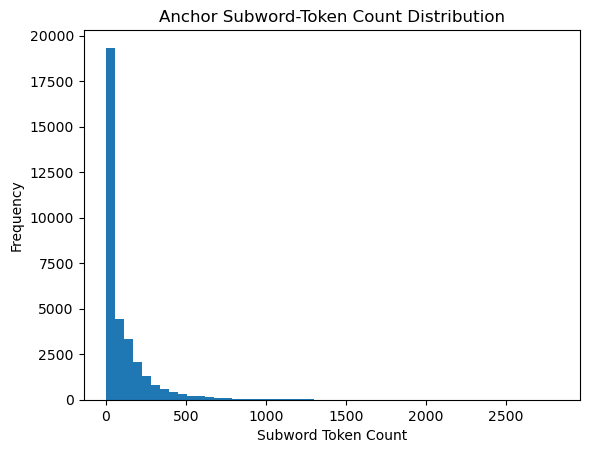

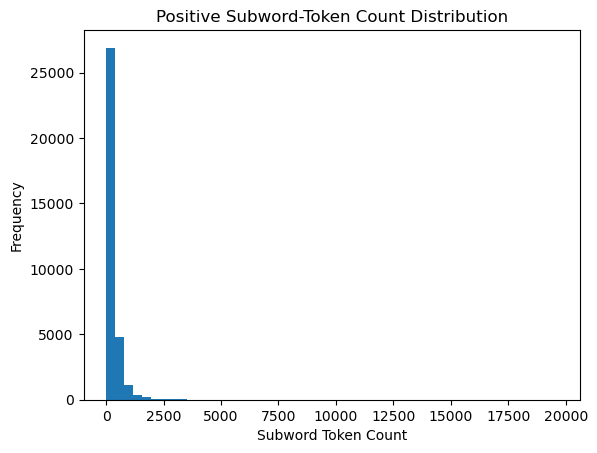

In [8]:
# 3️⃣ Plot distributions
plt.figure()
plt.hist(anchor_lens, bins=50)
plt.title('Anchor Subword‐Token Count Distribution')
plt.xlabel('Subword Token Count')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.hist(positive_lens, bins=50)
plt.title('Positive Subword‐Token Count Distribution')
plt.xlabel('Subword Token Count')
plt.ylabel('Frequency')
plt.show()

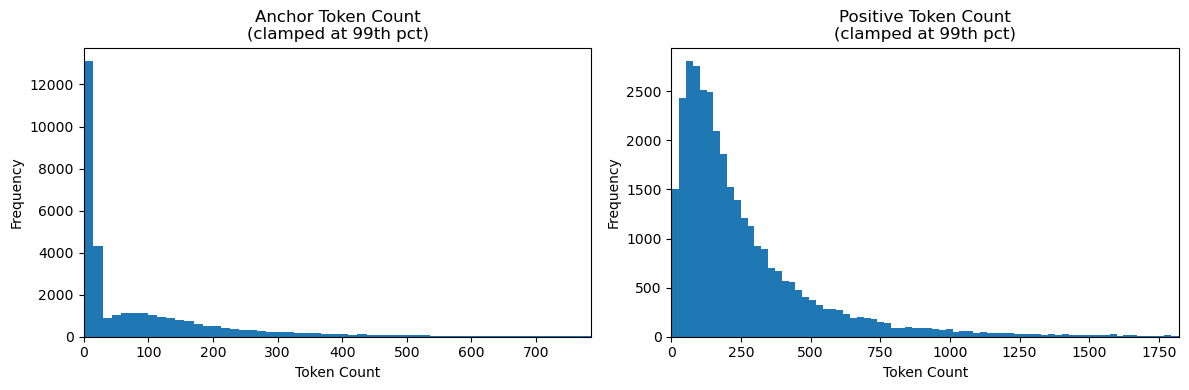

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Compute 99th percentiles
p99_anchor   = np.percentile(anchor_lens,   99)
p99_positive = np.percentile(positive_lens, 99)

# Create a 1×2 subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Anchor subplot
axes[0].hist(anchor_lens, bins=200)
axes[0].set_title('Anchor Token Count\n(clamped at 99th pct)')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, p99_anchor)

# Positive subplot
axes[1].hist(positive_lens, bins=800)
axes[1].set_title('Positive Token Count\n(clamped at 99th pct)')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, p99_positive)

plt.tight_layout()
plt.show()


In [1]:
from sentence_transformers import SentenceTransformer


model = SentenceTransformer(
        'nomic-ai/modernbert-embed-base',
        tokenizer_kwargs={"model_max_length": 1024, "truncation": True},
        # model_kwargs={"model_max_length": 1024}
    )


# tokenizer_kwargs={"model_max_length": MODEL_MAX_LEN, "truncation": True},
#         model_kwargs={"torch_dtype": torch.bfloat16 if bf16_supported else None, "max_seq_length": MODEL_MAX_LEN}

In [2]:
model.max_seq_length = 16

In [3]:
model[0]

Transformer({'max_seq_length': 16, 'do_lower_case': False, 'architecture': 'ModernBertModel'})

In [4]:
%%time
x = model.encode(["i am a sentence", "i am another sentence"])

CPU times: user 561 ms, sys: 469 ms, total: 1.03 s
Wall time: 1.64 s


In [15]:
x.shape

(2, 768)